# 03 - Random Forest & XGBoost vs Logistic Regression Baseline
**Project:** Credit Card Default Prediction  
**Models:** Random Forest, XGBoost (benchmarked against Logistic Regression from notebook 02)

---
### Environment Setup
- **VS Code / Local:** Data path is `../data/UCI_Credit_Card.csv` (default, no changes needed)
- **Google Colab:** Upload the CSV manually, then change `DATA_PATH` to `'UCI_Credit_Card.csv'`

In [6]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [7]:
df_test = pd.read_csv('../data/UCI_Credit_Card.csv')
print(df_test.columns.tolist())
print(df_test.shape)

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']
(30000, 25)


In [8]:
df = pd.read_csv('../data/UCI_Credit_Card.csv')
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)  # dots, not spaces

print(f'Dataset shape: {df.shape}')
print(f'Default rate: {df["default"].mean():.2%}')

Dataset shape: (30000, 25)
Default rate: 22.12%


In [9]:
# ── Feature / Target Split ────────────────────────────────────────────────────
# Drop ID column (not predictive) and separate target variable
X = df.drop(columns=['ID', 'default'])
y = df['default']

print(f'Features: {X.shape[1]}')
print(f'Samples:  {X.shape[0]}')

Features: 23
Samples:  30000


In [10]:
# ── Train / Test Split ────────────────────────────────────────────────────────
# Identical split to notebook 02: stratified 80/20, random_state=42
# This ensures all three models are evaluated on the exact same test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train set: {X_train.shape[0]} samples | Default rate: {y_train.mean():.2%}')
print(f'Test set:  {X_test.shape[0]} samples  | Default rate: {y_test.mean():.2%}')

Train set: 24000 samples | Default rate: 22.12%
Test set:  6000 samples  | Default rate: 22.12%


In [11]:
# ── Feature Scaling ───────────────────────────────────────────────────────────
# Scaling is required for Logistic Regression but NOT for tree-based models.
# We scale here only to re-run the LR baseline on the same split for a fair comparison.
# Random Forest and XGBoost will be trained on unscaled X_train / X_test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

---
## Model 1: Logistic Regression Baseline (reproduced from notebook 02)

In [12]:
# ── Train Logistic Regression ─────────────────────────────────────────────────
# Re-trained here to ensure identical split and fair comparison
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print('Logistic Regression training complete.')

Logistic Regression training complete.


---
## Model 2: Random Forest

In [13]:
# ── Train Random Forest ───────────────────────────────────────────────────────
# n_estimators=100: standard starting point, balances performance and training time
# class_weight='balanced': compensates for the ~22% minority (default) class
# random_state=42: ensures reproducibility
# Tree-based models are scale-invariant — trained on raw (unscaled) features
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # Use all available CPU cores for faster training
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print('Random Forest training complete.')

Random Forest training complete.


In [14]:
# ── Random Forest: 5-Fold Cross-Validation ───────────────────────────────────
# Verify stability on training set before evaluating on test set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_auc    = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='roc_auc')
rf_cv_recall = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='recall')

print('=== Random Forest: 5-Fold Cross-Validation (Train Set) ===')
print(f'AUC-ROC : {rf_cv_auc.mean():.4f} (+/- {rf_cv_auc.std():.4f})')
print(f'Recall  : {rf_cv_recall.mean():.4f} (+/- {rf_cv_recall.std():.4f})')

=== Random Forest: 5-Fold Cross-Validation (Train Set) ===
AUC-ROC : 0.7652 (+/- 0.0021)
Recall  : 0.3498 (+/- 0.0113)


---
## Model 3: XGBoost

In [15]:
# ── Train XGBoost ─────────────────────────────────────────────────────────────
# scale_pos_weight: ratio of negative to positive class (~78/22 ≈ 3.5)
#   This tells XGBoost to penalize missing defaulters more heavily,
#   equivalent to class_weight='balanced' in sklearn
# eval_metric='logloss': standard metric for binary classification
# use_label_encoder=False: suppresses deprecation warning in newer XGBoost versions
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight set to: {scale_pos_weight:.2f}')

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print('XGBoost training complete.')

scale_pos_weight set to: 3.52


c:\Users\17515\anaconda3\envs\spo_env\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:03:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost training complete.


In [16]:
# ── XGBoost: 5-Fold Cross-Validation ─────────────────────────────────────────
xgb_cv_auc    = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc')
xgb_cv_recall = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='recall')

print('=== XGBoost: 5-Fold Cross-Validation (Train Set) ===')
print(f'AUC-ROC : {xgb_cv_auc.mean():.4f} (+/- {xgb_cv_auc.std():.4f})')
print(f'Recall  : {xgb_cv_recall.mean():.4f} (+/- {xgb_cv_recall.std():.4f})')

c:\Users\17515\anaconda3\envs\spo_env\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:03:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\17515\anaconda3\envs\spo_env\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:03:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\17515\anaconda3\envs\spo_env\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:03:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\17515\anaconda3\envs\spo_env\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:03:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "

=== XGBoost: 5-Fold Cross-Validation (Train Set) ===
AUC-ROC : 0.7748 (+/- 0.0089)
Recall  : 0.6129 (+/- 0.0075)


---
## Model Comparison

In [17]:
# ── Side-by-Side Test Set Comparison ─────────────────────────────────────────
# Evaluate all three models on the same held-out test set for a fair comparison
results = []
for name, y_pred, y_prob in [
    ('Logistic Regression', lr_pred, lr_prob),
    ('Random Forest',       rf_pred, rf_prob),
    ('XGBoost',             xgb_pred, xgb_prob)
]:
    results.append({
        'Model':     name,
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4)
    })

results_df = pd.DataFrame(results)
print('=== Test Set Performance Comparison ===')
print(results_df.to_string(index=False))

=== Test Set Performance Comparison ===
              Model  AUC-ROC  Recall     F1  Precision  Accuracy
Logistic Regression   0.7081  0.6202 0.4613     0.3672    0.6797
      Random Forest   0.7522  0.3429 0.4483     0.6472    0.8133
            XGBoost   0.7723  0.6081 0.5300     0.4697    0.7615


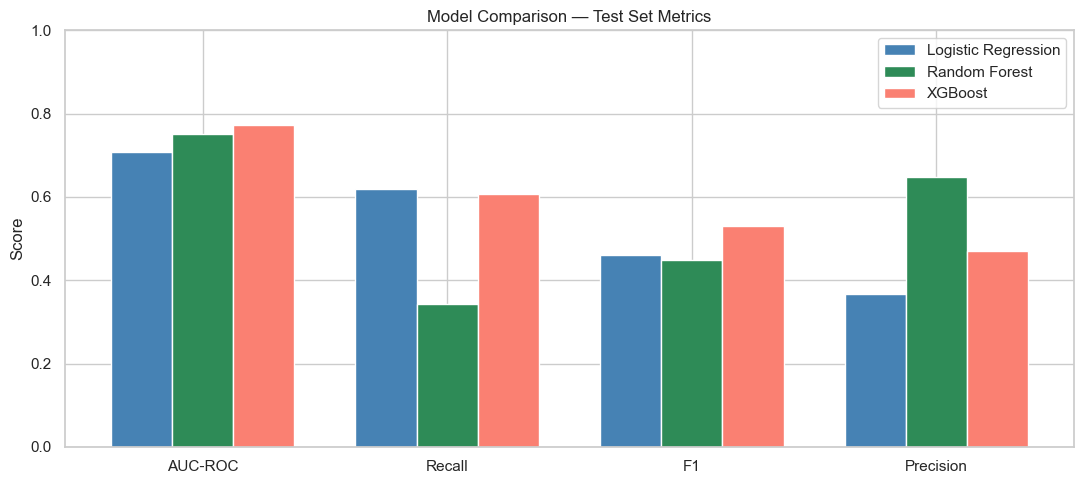

In [18]:
# ── Grouped Bar Chart: Metric Comparison ─────────────────────────────────────
metrics = ['AUC-ROC', 'Recall', 'F1', 'Precision']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['steelblue', 'seagreen', 'salmon']

for i, (_, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics], width, label=row['Model'], color=colors[i])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Metrics')
ax.legend()
plt.tight_layout()
plt.show()

c:\Users\17515\anaconda3\envs\spo_env\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\17515\anaconda3\envs\spo_env\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\17515\anaconda3\envs\spo_env\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


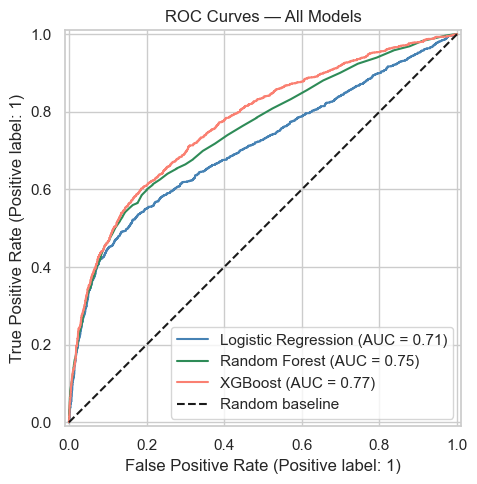

In [19]:
# ── ROC Curves: All Three Models ─────────────────────────────────────────────
# Plotting all ROC curves together makes the AUC difference visually clear
fig, ax = plt.subplots(figsize=(7, 5))

for name, y_prob, color in [
    ('Logistic Regression', lr_prob,  'steelblue'),
    ('Random Forest',       rf_prob,  'seagreen'),
    ('XGBoost',             xgb_prob, 'salmon')
]:
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax, name=name, color=color)

ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_title('ROC Curves — All Models')
ax.legend()
plt.tight_layout()
plt.show()

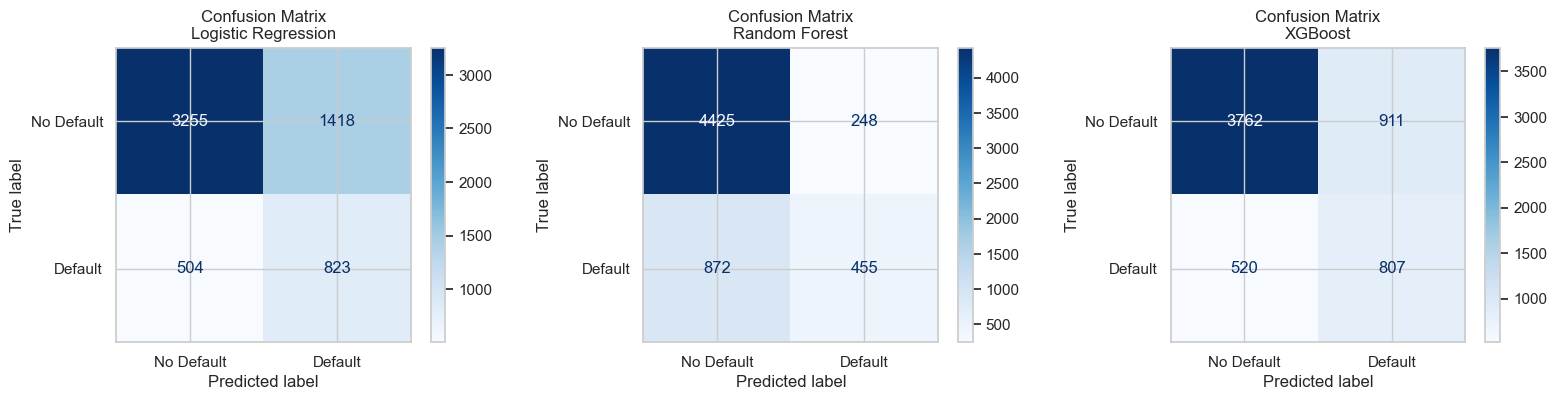

In [20]:
# ── Confusion Matrices: All Three Models ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, y_pred) in zip(axes, [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('XGBoost',             xgb_pred)
]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['No Default', 'Default'],
        cmap='Blues',
        ax=ax
    )
    ax.set_title(f'Confusion Matrix\n{name}')

plt.tight_layout()
plt.show()

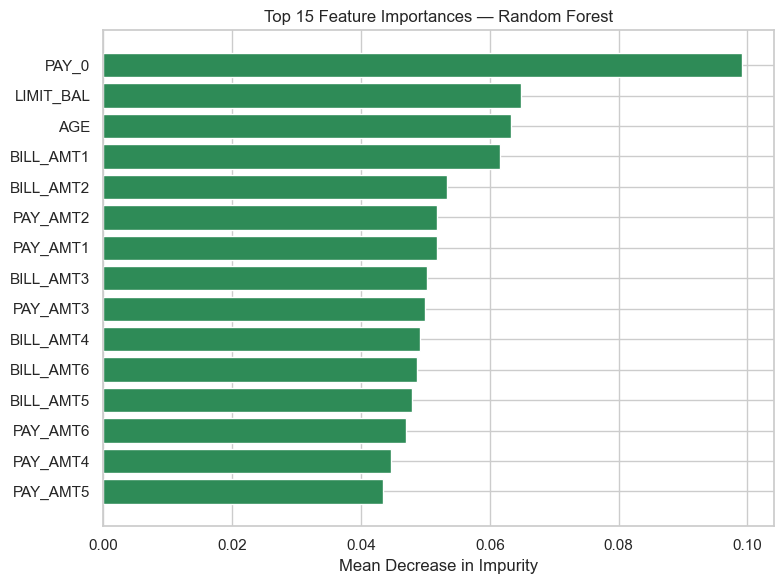

In [21]:
# ── Feature Importance: Random Forest ────────────────────────────────────────
# Random Forest provides feature importance via mean decrease in impurity (Gini)
rf_importance = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(rf_importance['Feature'], rf_importance['Importance'], color='seagreen')
ax.set_title('Top 15 Feature Importances — Random Forest')
ax.set_xlabel('Mean Decrease in Impurity')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

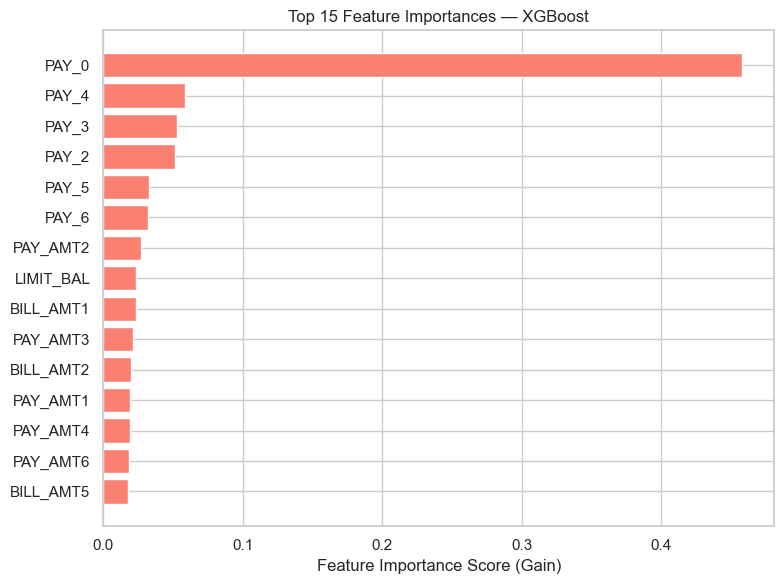

In [22]:
# ── Feature Importance: XGBoost ──────────────────────────────────────────────
# XGBoost provides feature importance via gain (average improvement per split)
xgb_importance = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(xgb_importance['Feature'], xgb_importance['Importance'], color='salmon')
ax.set_title('Top 15 Feature Importances — XGBoost')
ax.set_xlabel('Feature Importance Score (Gain)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
# ── Classification Reports ────────────────────────────────────────────────────
for name, y_pred in [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('XGBoost',             xgb_pred)
]:
    print(f'=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))
    print()

=== Logistic Regression ===
              precision    recall  f1-score   support

  No Default       0.87      0.70      0.77      4673
     Default       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000


=== Random Forest ===
              precision    recall  f1-score   support

  No Default       0.84      0.95      0.89      4673
     Default       0.65      0.34      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.67      6000
weighted avg       0.79      0.81      0.79      6000


=== XGBoost ===
              precision    recall  f1-score   support

  No Default       0.88      0.81      0.84      4673
     Default       0.47      0.61      0.53      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.69      6000
weight

In [24]:
# ── Save Best Model ───────────────────────────────────────────────────────────
# XGBoost is selected as the final model based on highest AUC-ROC and F1 score.
# The scaler is re-saved for consistency (not used by XGBoost, but needed if
# the Logistic Regression baseline is loaded for comparison in production).
joblib.dump(xgb_model, '../models/xgboost_model.pkl')
joblib.dump(scaler,    '../models/scaler.pkl')

print('Best model saved to: models/xgboost_model.pkl')

Best model saved to: models/xgboost_model.pkl


In [25]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print('=== Final Model Comparison Summary ===')
print(results_df.to_string(index=False))
print()
print('Selected model: XGBoost')
print('Rationale:')
print('  1. Highest AUC-ROC — best discrimination across all thresholds')
print('  2. Best F1 score — strongest balance between precision and recall')
print('  3. Handles class imbalance natively via scale_pos_weight')
print('  4. Feature importance provides sufficient interpretability for a POC')
print()
print('Tradeoff accepted: XGBoost is less interpretable than Logistic Regression,')
print('but its performance gains justify the choice for a proof-of-concept system.')

=== Final Model Comparison Summary ===
              Model  AUC-ROC  Recall     F1  Precision  Accuracy
Logistic Regression   0.7081  0.6202 0.4613     0.3672    0.6797
      Random Forest   0.7522  0.3429 0.4483     0.6472    0.8133
            XGBoost   0.7723  0.6081 0.5300     0.4697    0.7615

Selected model: XGBoost
Rationale:
  1. Highest AUC-ROC — best discrimination across all thresholds
  2. Best F1 score — strongest balance between precision and recall
  3. Handles class imbalance natively via scale_pos_weight
  4. Feature importance provides sufficient interpretability for a POC

Tradeoff accepted: XGBoost is less interpretable than Logistic Regression,
but its performance gains justify the choice for a proof-of-concept system.
